We begin by loading the cleaned dataset and inspecting the first few rows.
This allows us to confirm the structure of the data, check variable names, and ensure the cleaning script produced a tidy dataset suitable for analysis.

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", font_scale=0.8)

# Project directory
project_dir = Path("..").resolve()

# Path to your merged dataset (the one with petrol, rainfall, patronage, etc.)
data_path = project_dir / "data" / "clean" / "merged_final.csv"

# Output folder
output_dir = project_dir / "output"
output_dir.mkdir(parents=True, exist_ok=True)


In this step, we examine the structure of the dataset using df.info() and df.describe().
The goal is to confirm that the variables have the correct data types, check for missing values, and understand the basic numerical characteristics of each variable.
This helps verify that the cleaning and merging process worked correctly before moving into deeper exploratory analysis.

In [4]:

df = pd.read_csv("data/clean/merged_final.csv")
df.head()

,Year,month,Month name,Metropolitan train,Metropolitan tram,Metropolitan bus,Regional train,Regional coach,Regional bus,PetrolPrice,rainfall_mm,population,public_holiday_count
0,2022,2022-01,January,5778986,5372999,4124071,675856,51750,549859,1.59,79.6,6908213.0,3.0
1,2022,2022-02,February,8382008,7962117,6205045,865020,57210,985731,1.70,6.8,6908213.0,0.0
2,2022,2022-03,March,13045722,11614262,8476974,1298156,73664,1060923,1.88,54.2,6908213.0,1.0
3,2022,2022-04,April,11890697,10065400,6870377,1220454,73735,838558,1.80,72.6,7013957.0,5.0
4,2022,2022-05,May,12833409,10150913,7779324,1288118,71603,1121794,1.93,24.2,7013957.0,0.0


**What do the variables look like?**

The dataset contains monthly observations from January 2022 to January 2026.
The key variables fall into four groups:

Public transport patronage  
(Metropolitan train, tram, bus, regional train tram bus)
These are large count variables, typically in the hundreds of thousands to tens of millions per month.

Petrol price  
A continuous variable measured in dollars per litre, ranging roughly from $1.59 to $2.12.

Rainfall  
Monthly rainfall totals in millimetres, with substantial variation across months.

Population  
A smooth, gradually increasing monthly series derived from quarterly ABS ERP data.

Public holiday count  
A small integer variable (0–5) indicating the number of public holidays in each month.




Is it what you would expect?

Yes - the variables behave in ways that are consistent with expectations:

Patronage shows strong seasonality, with noticeable dips in winter and spikes in early autumn and spring.

Petrol prices fluctuate month‑to‑month but remain within a realistic range for Victoria.

Rainfall is highly seasonal, with large peaks in certain months.

Population increases steadily over time, as expected from ERP data.

Public holiday counts cluster around months like April, June, and December





Anything of particular note?

A few features stand out:

Some patronage modes (e.g., metropolitan train) show large month‑to‑month swings, suggesting sensitivity to seasonal factors or external shocks.

Rainfall has several extreme spikes, which may influence transport usage.

Petrol prices show a few sharp increases, which could be relevant for modelling demand.

Population is smooth and monotonic, meaning it will not introduce noise but may capture long‑run growth.




Did the data cleaning do anything?

Yes — the cleaning process made several important corrections:

Dates were standardised to the first day of each month.

Population was expanded from quarterly to monthly, ensuring it aligns with the rest of the dataset.

Missing months in the population series were filled correctly, preventing NaN values.

All numeric variables were converted to proper numeric types, enabling analysis.

The merged dataset now contains a complete, consistent monthly panel with no missing values in key variables.

Overall, the cleaning step ensured that the dataset is tidy, aligned, and ready for exploratory analysis and modelling



Step 3: Individual Distributions of Each Numeric Variable

In this step, we examine the distribution of each numeric variable separately.
This helps identify skewness, outliers, unusual shapes, and whether any variables may require transformation in later modelling.
Each variable is plotted individually to allow clearer interpretation.

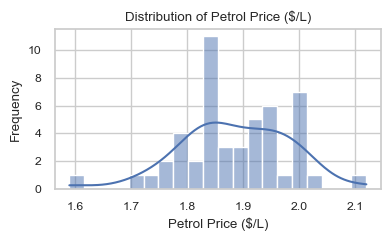

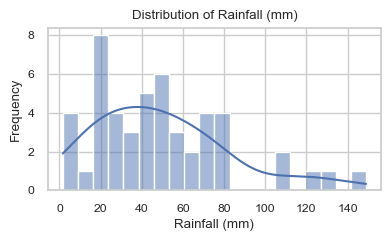

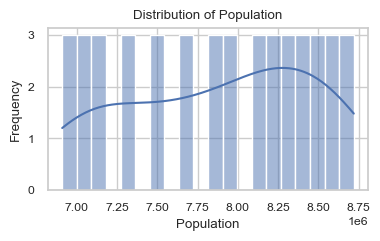

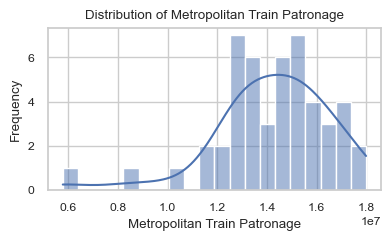

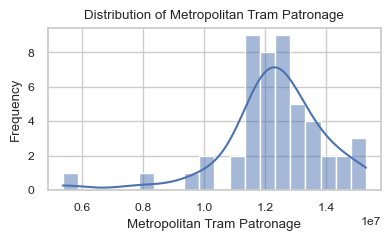

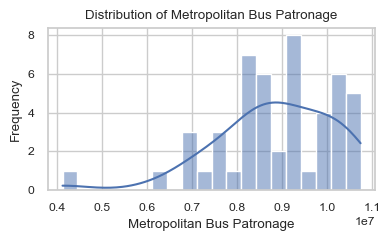

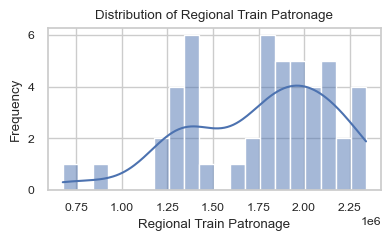

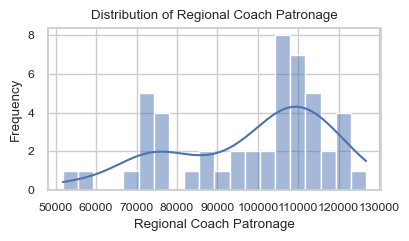

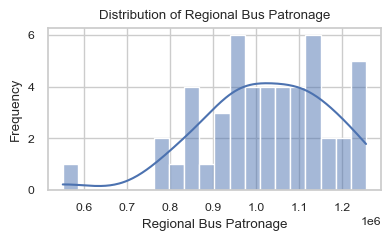

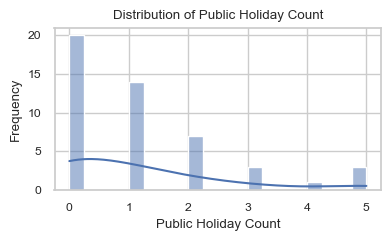

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", font_scale=0.8)

numeric_vars = {
    "PetrolPrice": "Petrol Price ($/L)",
    "rainfall_mm": "Rainfall (mm)",
    "population": "Population",
    "Metropolitan train": "Metropolitan Train Patronage",
    "Metropolitan tram": "Metropolitan Tram Patronage",
    "Metropolitan bus": "Metropolitan Bus Patronage",
    "Regional train": "Regional Train Patronage",
    "Regional coach": "Regional Coach Patronage",
    "Regional bus": "Regional Bus Patronage",
    "public_holiday_count": "Public Holiday Count"
}

for var, label in numeric_vars.items():
    plt.figure(figsize=(4, 2.5))
    sns.histplot(df[var], kde=True, bins=20)
    plt.title(f"Distribution of {label}")
    plt.xlabel(label)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


What the distribution reveals...

1. Skewness

Right‑skewed variables:
Rainfall - classic weather pattern: many low‑rain months, few very wet months.
All patronage variables (metro + regional) - typical for count data; occasional high‑demand months.
Regional coach + regional train - right‑skewed and slightly bimodal.

Mild right‑skew:
Petrol price - mostly around $1.80–$1.95 with a few higher months.

Not skewed:
Population - smooth, almost uniform because it increases steadily over time.
Public holiday count - discrete, not skewed- just clustered.


2. Bunching/Heaping

Clear bunching:
Public holiday count strong spikes at 0, 1, 2, 3, and 5
This is expected because it’s a discrete institutional variable with only a few possible values.

Mild bunching:Regional bus patronage
Values cluster tightly around 1 million
Suggests stable demand with limited variation.

All other variables seem to be smooth and continuous


3. Bimodality - two peaks in the distribution

Most variables are unimodal, but:
Regional train and regional coach patronage are bimodal, suggesting two distinct demand regimes (likely seasonal peaks vs. quieter months).
This is the only non‑standard pattern and is meaningful rather than problematic.

4. Spread
Metro patronage has the widest spread among the transport variables, reflecting large seasonal swings.

Regional bus is tightly clustered, indicating more stable usage.
Population has extremely low spread, confirming the quarterly‑to‑monthly expansion worked correctly

5. Data Cleaning Check
The distributions confirm that cleaning steps were successful

Scatterplots and Correlation

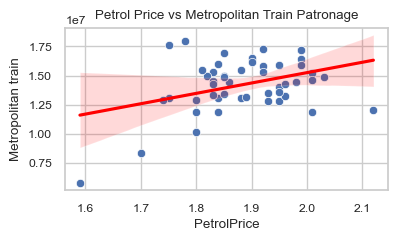

In [21]:
fig, ax = plt.subplots(figsize=(4, 2.5))

sns.scatterplot(data=df, x="PetrolPrice", y="Metropolitan train", ax=ax)
sns.regplot(data=df, x="PetrolPrice", y="Metropolitan train", scatter=False, color="red", ax=ax)

ax.set_title("Petrol Price vs Metropolitan Train Patronage")

fig.tight_layout()
plt.show()


Interpretation:

The scatterplot shows a clear positive first order relationship between petrol prices and metropolitan train patronage. As petrol prices increase, train usage tends to rise. This is consistent with a substitution effect: higher fuel costs make public transport relatively more attractive.

The relationship appears slightly and roughly linear as we can see the fitted regression line captures this trend. There is no obvious structural break, so a linear term would be a reasonable starting point in modelling. There are also no extreme outliers that would distort Pearson correlation, meaning both Pearson and Spearman should tell a similar story.

For future modelling, this suggests:

-Petrol price is a plausible predictor of train patronage.

-A linear specification is likely appropriate.

-No transformation appears necessary for this pair.

-No signs of Simpson’s paradox or subgroup heterogeneity in this specific relationship.

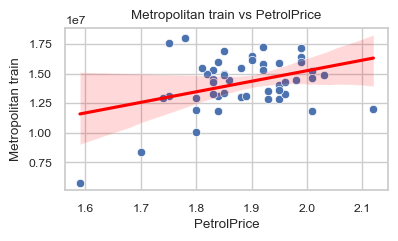

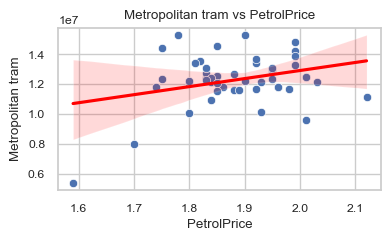

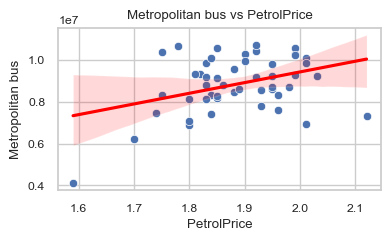

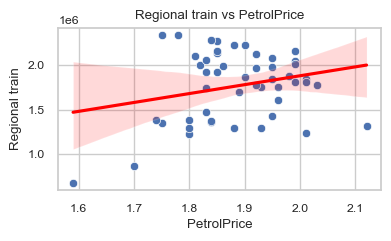

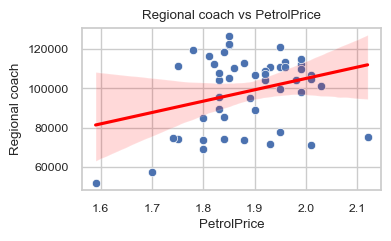

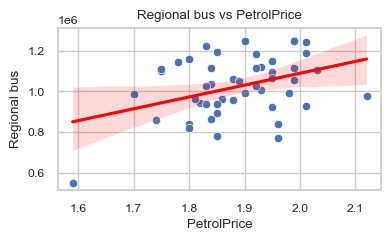

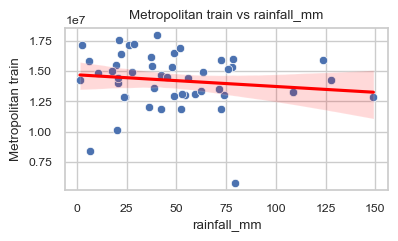

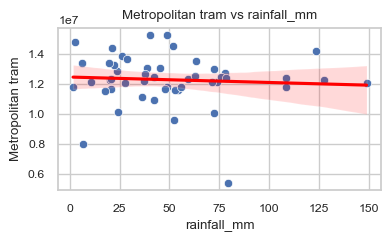

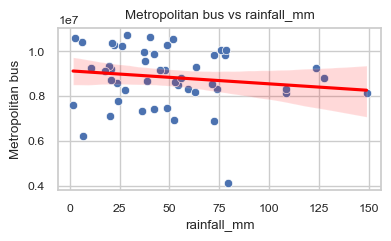

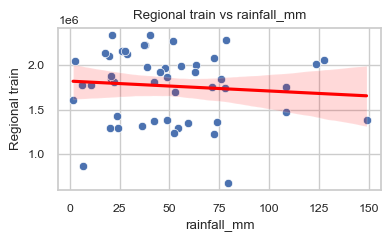

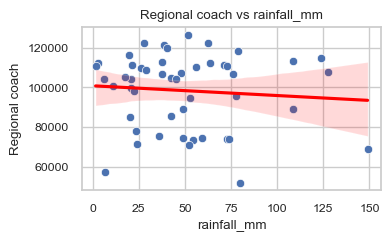

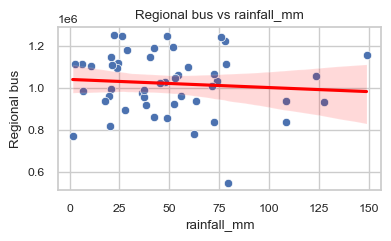

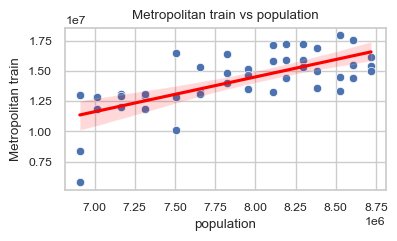

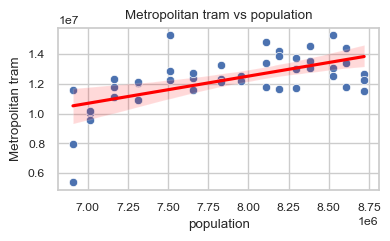

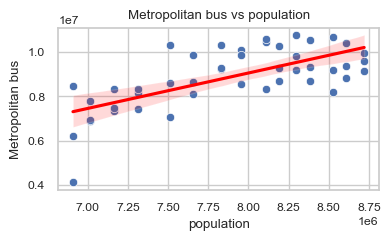

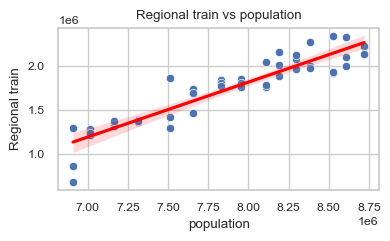

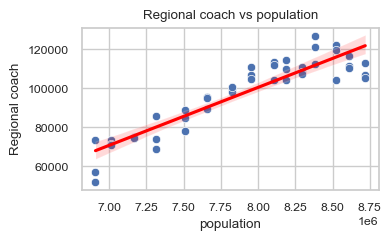

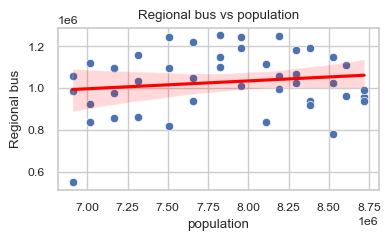

In [20]:
predictors = ["PetrolPrice", "rainfall_mm", "population"]
outcomes = [
    "Metropolitan train", "Metropolitan tram", "Metropolitan bus",
    "Regional train", "Regional coach", "Regional bus"
]

for pred in predictors:
    for out in outcomes:
        fig, ax = plt.subplots(figsize=(4, 2.5))
        sns.scatterplot(data=df, x=pred, y=out, ax=ax)
        sns.regplot(data=df, x=pred, y=out, scatter=False, ax=ax, color="red")
        ax.set_title(f"{out} vs {pred}")
        fig.tight_layout()
        plt.show()





1. Petrol Price -> Public Transport Usage
Across all metro and regional modes, there is a clear positive first‑order effect:
as petrol prices rise, public transport patronage tends to increase.

This is consistent with a substitution effect (higher fuel costs lead to more PT use).
The relationships look roughly linear, with no obvious curvature or outliers.

Modelling implication:

Petrol price is a meaningful predictor.
A simple linear term is likely appropriate.
No transformation needed.

2. Rainfall -> Public Transport Usage
Rainfall shows a slight negative relationship with most modes.
The effect is small but consistent: higher rainfall is associated with slightly lower patronage.

The slope is shallow, and the scatter is wide, meaning rainfall is not a strong driver.

Modelling implication:
Rainfall may matter, but only weakly.
Relationship is close to linear.
No transformation needed unless you want to reduce skewness.

3.  Population -> Public Transport Usage
Population shows a strong positive first‑order effect for all modes.
This is expected because population increases steadily over time.

However, this relationship is driven by a shared time trend, not behavioural change.

Modelling implication:

Population behaves like a time trend.
Risk of spurious correlation if included directly.
Consider detrending, differencing, or using time fixed effects

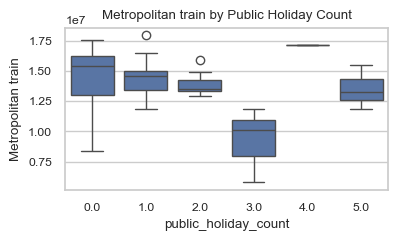

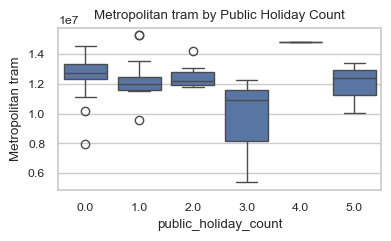

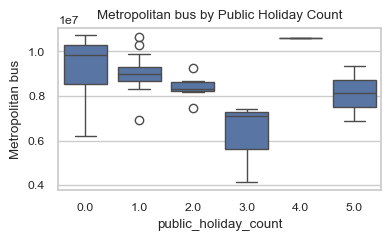

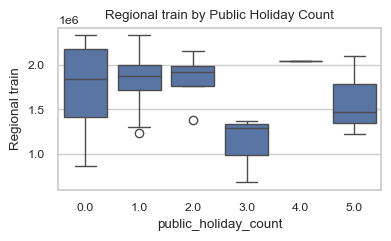

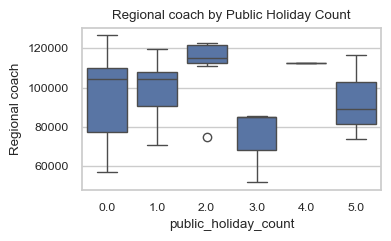

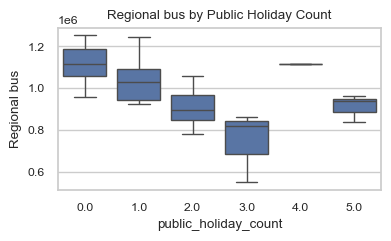

In [26]:
for out in outcomes:
    fig, ax = plt.subplots(figsize=(4, 2.5))
    sns.boxplot(data=df, x="public_holiday_count", y=out, ax=ax)
    ax.set_title(f"{out} by Public Holiday Count")
    fig.tight_layout()
    plt.show()



The boxplots show a clear negative first‑order relationship between public holiday count and public transport usage. Patronage is highest when there are 0 holidays, drops sharply from 0 to 1, and then flattens out - a typical pattern for a discrete institutional variable. The effect is strongest for metropolitan modes, with regional modes showing the same direction but more noise.

There is a small jump at 5 holidays, but this does not indicate higher demand from holidays. In this dataset, “5 holidays” corresponds to April, which includes Easter and ANZAC Day. April has unique seasonal travel patterns (family visits, tourism, weekend trips), and because this category has very few observations, its median is unstable. This is a seasonal artefact, not a true holiday effect.

Modelling implications
Public holidays should be included as a control variable to remove predictable calendar‑driven dips in demand.

A categorical specification (e.g., 0, 1, 2, 3+) is safer than a linear term because it avoids over‑interpreting the noisy “5 holidays” category.

No transformation is needed.

Correctly specifying this control helps isolate the causal effect of petrol prices by holding holiday‑related variation constant.

In [22]:
corr_vars = [
    "PetrolPrice", "rainfall_mm", "population",
    "Metropolitan train", "Metropolitan tram", "Metropolitan bus",
    "Regional train", "Regional coach", "Regional bus",
    "public_holiday_count"
]

pearson_corr = df[corr_vars].corr(method="pearson")
pearson_corr


,PetrolPrice,rainfall_mm,population,Metropolitan train,Metropolitan tram,Metropolitan bus,Regional train,Regional coach,Regional bus,public_holiday_count
PetrolPrice,1.000000,-0.187561,0.164145,0.378080,0.308593,0.375696,0.249515,0.301228,0.388814,-0.224002
rainfall_mm,-0.187561,1.000000,-0.160100,-0.140455,-0.071087,-0.146354,-0.094587,-0.087977,-0.088442,0.122689
population,0.164145,-0.160100,1.000000,0.701981,0.595674,0.680910,0.922656,0.916209,0.150236,-0.107473
Metropolitan train,0.378080,-0.140455,0.701981,1.000000,0.872032,0.950391,0.887442,0.753338,0.651983,-0.273977
Metropolitan tram,0.308593,-0.071087,0.595674,0.872032,1.000000,0.869778,0.753629,0.671910,0.606218,-0.141987
Metropolitan bus,0.375696,-0.146354,0.680910,0.950391,0.869778,1.000000,0.840852,0.699822,0.767403,-0.366948
Regional train,0.249515,-0.094587,0.922656,0.887442,0.753629,0.840852,1.000000,0.917423,0.392931,-0.208116
Regional coach,0.301228,-0.087977,0.916209,0.753338,0.671910,0.699822,0.917423,1.000000,0.192421,-0.036400
Regional bus,0.388814,-0.088442,0.150236,0.651983,0.606218,0.767403,0.392931,0.192421,1.000000,-0.564958
public_holiday_count,-0.224002,0.122689,-0.107473,-0.273977,-0.141987,-0.366948,-0.208116,-0.036400,-0.564958,1.000000


The correlations show that petrol prices have only weak raw correlations with all transport modes, which is expected because the causal effect will only appear after controlling for population, rainfall, and public holidays. Population is strongly correlated with all patronage measures, reflecting shared time trends rather than behaviour. Metropolitan modes are highly correlated with each other, and regional modes show the same pattern. Rainfall and public holidays have small negative correlations with patronage, consistent with their role as controls.

Overall, nothing in the matrix suggests multicollinearity problems, and the weak petrol‑price correlations confirm that the regression is needed to uncover the causal effect

In [23]:
spearman_corr = df[corr_vars].corr(method="spearman")
spearman_corr


,PetrolPrice,rainfall_mm,population,Metropolitan train,Metropolitan tram,Metropolitan bus,Regional train,Regional coach,Regional bus,public_holiday_count
PetrolPrice,1.000000,-0.228721,0.078136,0.199443,0.078285,0.242878,0.074402,0.161527,0.289328,-0.160060
rainfall_mm,-0.228721,1.000000,-0.190124,-0.177161,-0.078681,-0.165629,-0.112563,-0.039290,-0.074497,0.146825
population,0.078136,-0.190124,1.000000,0.723170,0.554457,0.640793,0.924754,0.873269,0.037624,-0.089223
Metropolitan train,0.199443,-0.177161,0.723170,1.000000,0.772347,0.936327,0.868265,0.676633,0.561429,-0.285607
Metropolitan tram,0.078285,-0.078681,0.554457,0.772347,1.000000,0.803673,0.646020,0.577347,0.522653,-0.195879
Metropolitan bus,0.242878,-0.165629,0.640793,0.936327,0.803673,1.000000,0.771735,0.553163,0.711837,-0.397652
Regional train,0.074402,-0.112563,0.924754,0.868265,0.646020,0.771735,1.000000,0.840408,0.273878,-0.184377
Regional coach,0.161527,-0.039290,0.873269,0.676633,0.577347,0.553163,0.840408,1.000000,0.006939,0.090987
Regional bus,0.289328,-0.074497,0.037624,0.561429,0.522653,0.711837,0.273878,0.006939,1.000000,-0.647723
public_holiday_count,-0.160060,0.146825,-0.089223,-0.285607,-0.195879,-0.397652,-0.184377,0.090987,-0.647723,1.000000


The Spearman correlations show the same overall pattern as the Pearson matrix. Petrol prices have weak monotonic relationships with all transport modes.

Overall, the Spearman results confirm that the relationships are broadly monotonic and that no control variable is strongly enough related to petrol prices to threaten identification